No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


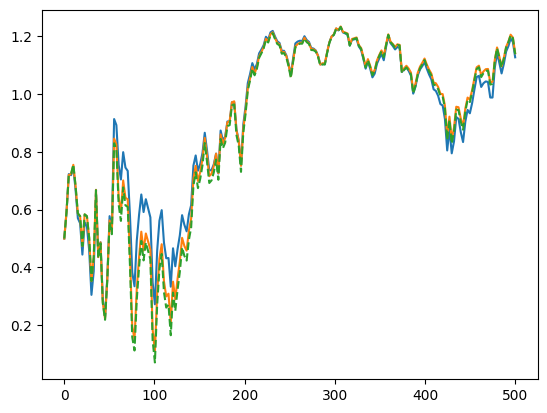

In [1]:
import jax
import jax.numpy as jnp

from probjax.utils.sdeint import sdeint

import matplotlib.pyplot as plt


# Define the ODE
def f(t, x):
    return -(1 / 10)**2 * jnp.sin(x)*jnp.cos(x)**3 

def g(t, x):
    return 1/10 * jnp.cos(x)**2

def f_true(Wt,t, x0):
    return jnp.arctan(1/10 * Wt + jnp.tan(x0))

# Define the initial condition
x0 = jnp.ones((1,))*0.5

# Define the time points to evaluate
t = jnp.linspace(0., 500., 200)

# Solve the ODE
key = jax.random.PRNGKey(2)
x,W  = sdeint(key, f, g, x0, t, method="euler_maruyama", noise_type="diagonal", return_brownian=True)
#with jax.disable_jit():
x2, W2= sdeint(key, f, g, x0, t, method="sri2", noise_type="diagonal", return_brownian=True)
y = f_true(W, t, x0)


# Plot the solution

plt.plot(t, x)
plt.plot(t, x2)
plt.plot(t, f_true(W , t, x0), "--")

In [ ]:
def _exect_lin

(0.0, 1.0)

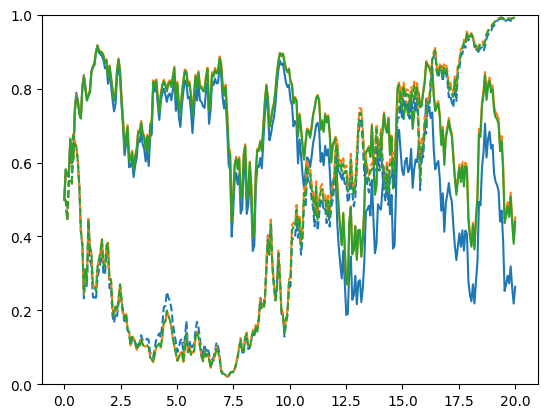

In [12]:
d = 2
m = 2

def f2(t,x):
    return 0.5 * x*(1-x) * (1- 2*x)

def g2(t,x):
    return jnp.diag(x * (1-x))

def f2_true(Wt,t,x0):
    return 1/(1 + jnp.exp(-Wt + jnp.log(x0/(1-x0)).reshape(-1,2)))

x0 = jnp.array([0.5, 0.5])
t = jnp.linspace(0., 20., 300)
key = jax.random.PRNGKey(0)
x,W  = sdeint(key, f2, g2, x0, t, method="euler_maruyama", noise_type="general", return_brownian=True)
#with jax.disable_jit():
x2, W2= sdeint(key, f2, g2, x0, t, method="milstein",noise_type="general", return_brownian=True)
y = f2_true(W, t, x0)

plt.plot(t, x[:,0])
plt.plot(t, x2[:,0])
plt.plot(t, f2_true(W , t, x0)[:,0])

plt.plot(t, x[:,1], '--', color='C0')
plt.plot(t, x2[:,1], '--', color='C1')
plt.plot(t, f2_true(W , t, x0)[:,1], '--', color='C2')

plt.ylim(0,1)

In [ ]:
d = 2
m = 2

A = jnp.array([[-1, 0.5], [0.5, -1]])
B = jnp.array([[1, 0.1], [0.1, 1]]) * 0.1

def f2(t,x):
    return jnp.matmul(A, x)

def g2(t,x):
    return B

def f2_true(Wt,t,x0):
    
    

x0 = jnp.array([0.5, 0.5])
t = jnp.linspace(0., 20., 300)
key = jax.random.PRNGKey(0)
x,W  = sdeint(key, f2, g2, x0, t, method="euler_maruyama", noise_type="general", return_brownian=True)
#with jax.disable_jit():
x2, W2= sdeint(key, f2, g2, x0, t, method="milstein",noise_type="general", return_brownian=True)
y = f2_true(W, t, x0)

plt.plot(t, x[:,0])
plt.plot(t, x2[:,0])
plt.plot(t, f2_true(W , t, x0)[:,0])

plt.plot(t, x[:,1], '--', color='C0')
plt.plot(t, x2[:,1], '--', color='C1')
plt.plot(t, f2_true(W , t, x0)[:,1], '--', color='C2')

plt.ylim(0,1)

In [12]:


def f2(t,x):
    return 0.5 * x*(1-x) * (1- 2*x)

def g2(t,x):
    return jnp.diag(x * (1-x))

n = 3
m = n
y0 = jnp.array([0.5, 0.5, 0.5])

f0 = f2(0, y0)
g0 = g2(0, y0)




t0 = 0.
dt = 0.1
dWt = jax.random.normal(key,shape=(m,)) * jnp.sqrt(dt)
dWtdWs = jnp.outer(dWt, dWt)

A0 = jnp.array([[0,0,0], [1.,0,0], [0,0.,0]])
A1 =  jnp.array([[0,0,0], [1.,0,0], [1,0.,0]])
B0 =  jnp.array([[0,0,0], [1.,0,0], [1,0.,0]])
B1 = jnp.array([[0,0,0], [1.,0,0], [-1,0.,0]])
c0 = jnp.array([0,1,0])
c1 = jnp.array([0,1,1])
alpha1 = jnp.array([0.5,0.5,0])
beta1 = jnp.array([1,0,0])
beta2 = jnp.array([0, 0.5, -0.5])

k1 = jnp.zeros((3,) + f0.shape, f0.dtype).at[0, :].set(f0)
k2 = (
        jnp.zeros((3,g0.shape[1]) + g0.shape, g0.dtype).at[0, :].set(g0)
    )  # Diffusion evaluations at support points
for i in range(1,3):
    t1 = t0 + c0[i]*dt
    t2 = t0 + c1[i]*dt
    y1 = y0 + jnp.dot(A0[i, :], k1) * dt + 1/3*jnp.einsum("s, smij, j -> j", B0[i, :], k2, dWt)
    y2 = y0 + jnp.dot(A1[i, :], k1) * dt 
    y2 = jnp.broadcast_to(y2, (m,n))
    
    for k in range(2):
        y2_k = jnp.einsum('s,smim,m->i', B1[i], k2, dWtdWs[:,k]) / jnp.sqrt(dt)
        y2 = y2.at[k, :].set(y2_k + y2[k,:])

    y1_true = y0
    for j in range(3):
        y1_true += A0[i,j] * k1[j] * dt 
        for l in range(m):
            y1_true += B0[i,j] * k2[j,l,l] * dWt[l]

    y2s = jnp.zeros((m,n))
    for k in range(m):
        y2_true = y0
        for j in range(3):
            y2_true += A1[i,j] * k1[j] * dt 
            for l in range(m):
                y2_true += B1[i,j] * k2[j,l,:,l] * dWtdWs[l,k] / jnp.sqrt(dt)
        y2s = y2s.at[k, :].set(y2_true)


    print("Compare 1:", y1_true, y1)
    print("Compare 2:", y2s, y2)


    fnew = f2(t1, y1)
    gnew = jax.vmap(g2, in_axes=(None, 0))(t2, y2)

    k1 = k1.at[i, :].set(fnew)
    k2 = k2.at[i, :].set(gnew)

    



y1 = y0 + jnp.dot(alpha1, k1) * dt + jnp.einsum("s, smij, j -> i", beta1, k2, dWt) + jnp.einsum("s, smij, j -> i", beta2, k2, jnp.ones_like(dWt)*jnp.sqrt(dt))

y1

Compare 1: [0.5338771 0.5852076 0.5128972] [0.5338771 0.5852076 0.5128972]
Compare 2: [[0.51451683 0.53651273 0.50552666]
 [0.53651273 0.5918368  0.5139006 ]
 [0.50552666 0.5139006  0.50210404]] [[0.51451683 0.53651273 0.50552666]
 [0.53651273 0.5918368  0.5139006 ]
 [0.5        0.5        0.5       ]]
Compare 1: [0.5338771 0.5852076 0.5128972] [0.5338771 0.5852076 0.5128972]
Compare 2: [[0.48548317 0.46348727 0.49447337]
 [0.46348727 0.40816322 0.48609942]
 [0.49447337 0.48609942 0.497896  ]] [[0.48548317 0.46348727 0.49447337]
 [0.46348727 0.40816322 0.48609942]
 [0.5        0.5        0.5       ]]


Array([0.60120976, 0.7545886 , 0.5385304 ], dtype=float32)

In [116]:
jnp.dot(A1[1, :], k1) * dt

Array([0.75, 0.75], dtype=float32)

In [74]:
C = dWtdWs / jnp.sqrt(dt)

C = C.reshape((-1, 2))
C

Array([[ 0.19475128, -0.21253945],
       [-0.21253945,  0.23195237]], dtype=float32)

In [31]:
jnp.einsum("s, smij, jj -> ij", B1[i, :], k2, dWtdWs / jnp.sqrt(dt))

Array([[-0.09737564,  0.        ],
       [ 0.        , -0.11597618]], dtype=float32)

In [15]:
jnp.einsum("s, smij, j -> mj", B1[i, :], k2, dWt)

Array([[ 0.0620412 , -0.06770791],
       [ 0.0620412 , -0.06770791]], dtype=float32)

In [65]:


k = 0
k2 = jnp.zeros((3,2) + g0.shape, g0.dtype).at[0, :].set(g0)

for i in range(1,3):
    out = y0 + jnp.dot(A1[i, :], k1) * dt + jnp.einsum("s, smij, ij -> ij", B1[i, :], k2, dWtdWs[:, :] / jnp.sqrt(dt))
    gnew = jax.vmap(g2, in_axes=(None, 0))(t2, out)
    print(out)
    k2 = k2.at[i, ...].set(gnew)

k2


[[0.59737563 0.5       ]
 [0.5        0.6159762 ]]
[[0.40262437 0.5       ]
 [0.5        0.38402382]]


Array([[[[0.25      , 0.        ],
         [0.        , 0.25      ]],

        [[0.25      , 0.        ],
         [0.        , 0.25      ]]],


       [[[0.24051799, 0.        ],
         [0.        , 0.25      ]],

        [[0.25      , 0.        ],
         [0.        , 0.23654951]]],


       [[[0.24051799, 0.        ],
         [0.        , 0.25      ]],

        [[0.25      , 0.        ],
         [0.        , 0.23654954]]]], dtype=float32)

In [64]:
i = 1
jnp.einsum("s, sij, jk -> ik", B1[i, :], k2, dWtdWs / jnp.sqrt(dt))

Array([[ 0.04868782, -0.05313486],
       [-0.05313486,  0.05798809]], dtype=float32)

In [161]:
jnp.einsum("s, sij, i -> i", beta2, k2, jnp.ones_like(dWt)*jnp.sqrt(dt))

Array([ 0.0000000e+00, -3.7252903e-09], dtype=float32)

In [162]:
out = 0
for i in range(3):
    for k in range(2):
        out += beta2[i] * k2[i, k] * jnp.sqrt(dt)

out

Array([ 0.0000000e+00, -3.7252903e-09], dtype=float32)

In [146]:
jnp.einsum("s, sij -> ij", B0[i, :], k2) @ dWt

Array([-0.0620412 ,  0.06770791], dtype=float32)

In [150]:
jnp.einsum("s, sij, i -> i", B0[i, :], k2, dWt)

Array([-0.0620412 ,  0.06770791], dtype=float32)

In [139]:
jnp.einsum("s, sij -> ij", B1[i, :], k2) @ (dWtdWs / jnp.sqrt(dt))

Array([[-0.04868782,  0.05313486],
       [ 0.05313486, -0.05798809]], dtype=float32)

In [144]:
jnp.einsum("s, sij, jk -> i", B1[i, :], k2, dWtdWs / jnp.sqrt(dt))

Array([ 0.00444704, -0.00485323], dtype=float32)

(2, 2)
(99, 2)
(99, 2)


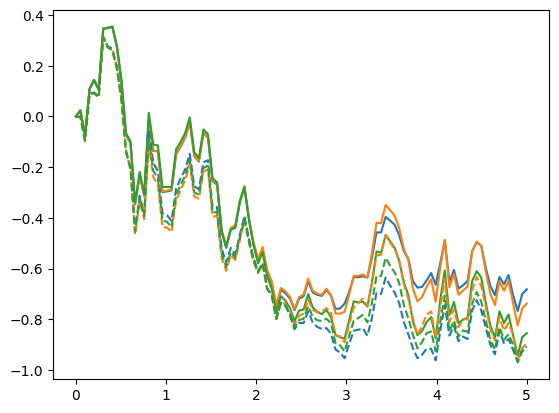

In [76]:
d = 2
m = 2

B = jnp.array([[0.1, 0.5], [0.01, 0.5]])

def f2(t,x):
    return -0.5 * jnp.dot(B,B)@x

def g2(t,x):
    return B @ (jnp.eye(2) * jnp.sqrt(( 1 - x**2)))

def f2_true(Wt,t,x0):
    return jnp.sin(jnp.dot(B, Wt.T).T)

x0 = jnp.array([0., 0.])
t = jnp.linspace(0., 5., 100)
key = jax.random.PRNGKey(0)
x,W  = sdeint(key, f2, g2, x0, t, method="milstein", noise_type="general", return_brownian=True)
x2, W2= sdeint(key, f2, g2, x0, t, noise_type="general", return_brownian=True)
y = f2_true(W, t, x0)

plt.plot(t, x[:,0])
plt.plot(t, x2[:,0])
plt.plot(t, f2_true(W , t, x0)[:,0])

plt.plot(t, x[:,1], '--', color='C0')
plt.plot(t, x2[:,1], '--', color='C1')
plt.plot(t, f2_true(W , t, x0)[:,1], '--', color='C2')


In [2]:
_sdeint_milstein = jax.vmap(lambda *args: sdeint(*args, method="milstein", return_brownian=True), in_axes=(0, None, None, None, None))
_sdeint = jax.vmap(sdeint, in_axes=(0, None, None, None, None))

ys = _sdeint(jax.random.split(key, (1000,)), f, g, x0, t)
ys_milstein, W = _sdeint_milstein(jax.random.split(key, (1000,)), f, g, x0, t)

true_sol = f_true(W, t, x0).reshape(1000, -1, 1)

ValueError: Einstein sum subscript 'nm' does not contain the correct number of indices for operand 0.

In [3]:
# Weak error
weak_error = jnp.abs(true_sol.mean(0)-ys_milstein.mean(0)).max()
# Strong error 
strong_error = jnp.mean(jnp.abs(true_sol-ys_milstein), (0,)).max()

print(weak_error, strong_error)

0.02677393 0.026773816


In [4]:
# Weak error
weak_error = jnp.abs(true_sol.mean(0)-ys.mean(0)).max()
# Strong error 
strong_error = jnp.mean(jnp.abs(true_sol-ys), (0,)).max()

print(weak_error, strong_error)

0.026658893 0.026658779


In [117]:
# Scalar case 

x = jnp.ones((1,))*0.5
t = jnp.ones((1,))

def g(t,x):
    return 2 * x

I = jnp.ones((1,))
g_grad = jax.jacfwd(g, argnums=1) 
B = g(t,x)  
B_grad = g_grad(t,x)

In [120]:
jnp.einsum("ij, i, i -> i", B_grad, I, B)

Array([2.], dtype=float32)

In [77]:
n = 10
m = 5

x = jnp.ones((n,))*2
t = jnp.ones((1,))

A = jax.random.normal(key, (m,n))

def g(t, x):
    return jnp.dot(A,x)

I = jnp.eye(m)

g_grad = jax.jacfwd(lambda t, x: g(t, x), argnums=1)

x = jnp.ones((n,))*2
B = g(t[0], x[0])
B_grad = g_grad(t[0], x[0])


In [104]:
jnp.sum(jnp.dot(B_grad.T, jnp.dot(I,B)), -1)

Array([15.879656, 13.387117, -7.116289, -8.298741, 23.387812,  8.457748,
       17.470886,  5.299798, 28.440659,  5.832735], dtype=float32)

In [115]:
jnp.sum(jnp.dot(jnp.dot(B_grad.T, I), B), -1)

Array([15.879656, 13.387117, -7.116289, -8.298741, 23.387812,  8.457748,
       17.470886,  5.299798, 28.440659,  5.832735], dtype=float32)

In [112]:
jnp.einsum("nm, mm, mn -> n", B_grad.T, I, B)

Array([ 2.9203613,  4.8145022,  6.030593 ,  2.458233 , 11.969267 ,
       15.738162 ,  6.035323 ,  6.5427694, 11.042926 ,  6.8474655],      dtype=float32)

In [26]:
# %%timeit 
g_grad(t[0], x[0])

Array([ 2.,  8., 24.], dtype=float32)

In [61]:
B@I@B_grad.T

Array([[12744., 12744.],
       [12744., 12744.]], dtype=float32)

In [43]:
for j in range(m):
    for a in range(n):
        for b in range(n):
            B_grad[j,a,b] = jax.grad(lambda x: g(t[0], x)[j,a])(x[b])

TypeError: '<class 'jaxlib.xla_extension.ArrayImpl'>' object does not support item assignment. JAX arrays are immutable. Instead of ``x[idx] = y``, use ``x = x.at[idx].set(y)`` or another .at[] method: https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.ndarray.at.html

In [87]:
jnp.einsum("i,i,i->i",jnp.ones((3,))*10, jnp.ones((3,))*10, jnp.ones((3,))*10)

Array([1000., 1000., 1000.], dtype=float32)

In [88]:
jnp.einsum("i,ij,j->i",jnp.ones((3,))*10, jnp.ones((3,3))*10, jnp.ones((3,))*10)

Array([3000., 3000., 3000.], dtype=float32)

In [80]:
import jax
import jax.numpy as jnp


def Ikpw(key, dW, dt, n=5):
    """matrix I approximating repeated Ito integrals for each of N time
    intervals, based on the method of Kloeden, Platen and Wright (1992).

    Args:
      dW (array of shape (N, m)): giving m independent Wiener increments for
        each time step N. (You can make this array using sdeint.deltaW())
      h (float): the time step size
      n (int, optional): how many terms to take in the series expansion
      key (jax.random.PRNGKey, optional)

    Returns:
      (A, I) where
        A: array of shape (N, m, m) giving the Levy areas that were used.
        I: array of shape (N, m, m) giving an m x m matrix of repeated Ito
        integral values for each of the N time intervals.
    """
    dW = jnp.atleast_1d(dW)
    m = dW.shape[0]

    sqrt2h = jnp.sqrt(2.0/dt)

    def body_fun(i, val):
        key, A0 = val
        next_key, key1, key2 = jax.random.split(key,3)
        Xk = jax.random.normal(key1, shape=(m,))
        Yk = jax.random.normal(key2, shape=(m,))
        term1 = jnp.outer(Xk, (Yk + sqrt2h*dW))
        term2 = jnp.outer(Yk + sqrt2h*dW, Xk)
        A1 = A0 + (term1 - term2)/i

        return (next_key, A1)

    A0 = jnp.zeros((m,m))
    init_val = (key, A0)

    _, A1 = jax.lax.fori_loop(1, n+1, body_fun, init_val)

    A1 = (dt/(2.0*jnp.pi))*A1
    I = 0.5*(jnp.outer(dW,dW)  - dt*jnp.eye(m)) + A1

    return I, A1

def Jkpw(key, dW, dt, n=5):
    I, A = Ikpw(key, dW, dt, n)
    J = I + 0.5 * dt * jnp.eye(dW.shape[0])
    return J, A






In [84]:
Ikpw(jax.random.PRNGKey(2), jnp.array(dW_test).squeeze(0), 0.1, n=100)[0]

Array([[-0.04373574,  0.01142397],
       [-0.05698499,  0.03284313]], dtype=float32)

In [55]:

dW_test = deltaW(1, 2, 0.1)
Ikpw(dW_test, 0.1, n=100)[1]

array([[[-0.04373573, -0.00904212],
        [-0.03651889,  0.03284314]]])

In [43]:
# Copyright 2015-2022 Matthew J. Aburn
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version. See <http://www.gnu.org/licenses/>.

r"""
Simulation of standard multiple stochastic integrals, both Ito and Stratonovich
I_{ij}(t) = \int_{0}^{t}\int_{0}^{s} dW_i(u) dW_j(s)  (Ito)
J_{ij}(t) = \int_{0}^{t}\int_{0}^{s} \circ dW_i(u) \circ dW_j(s)  (Stratonovich)

These multiple integrals I and J are important building blocks that will be
used by most of the higher-order algorithms that integrate multi-dimensional
SODEs.

We first implement the method of Kloeden, Platen and Wright (1992) to
approximate the integrals by the first n terms from the series expansion of a
Brownian bridge process. By default using n=5.

Finally we implement the method of Wiktorsson (2001) which improves on the
previous method by also approximating the tail-sum distribution by a
multivariate normal distribution.

References:
  P. Kloeden, E. Platen and I. Wright (1992) The approximation of multiple
    stochastic integrals
  M. Wiktorsson (2001) Joint Characteristic Function and Simultaneous
    Simulation of Iterated Ito Integrals for Multiple Independent Brownian
    Motions
"""

import numpy as np


def deltaW(N, m, h, generator=None):
    """Generate sequence of Wiener increments for m independent Wiener
    processes W_j(t) j=0..m-1 for each of N time intervals of length h.

    Args:
      N (int): number of time steps
      m (int): number of Wiener processes
      h (float): the time step size
      generator (numpy.random.Generator, optional)

    Returns:
      dW (array of shape (N, m)): The [n, j] element has the value
      W_j((n+1)*h) - W_j(n*h)
    """
    if generator is None:
        generator = np.random.default_rng()
    return generator.normal(0.0, np.sqrt(h), (N, m))


def _t(a):
    """transpose the last two axes of a three axis array"""
    return a.transpose((0, 2, 1))


def _dot(a, b):
    r""" for rank 3 arrays a and b, return \sum_k a_ij^k . b_ik^l (no sum on i)
    i.e. This is just normal matrix multiplication at each point on first axis
    """
    return np.einsum('ijk,ikl->ijl', a, b)


def _Aterm(N, h, m, k, dW, generator):
    """kth term in the sum of Wiktorsson2001 equation (2.2)"""
    sqrt2h = np.sqrt(2.0/h)
    Xk = generator.standard_normal((N, m, 1))
    Yk = generator.standard_normal((N, m, 1))
    term1 = _dot(Xk, _t(Yk + sqrt2h*dW))
    term2 = _dot(Yk + sqrt2h*dW, _t(Xk))
    return (term1 - term2)/k


def Ikpw(dW, h, n=5, generator=None):
    """matrix I approximating repeated Ito integrals for each of N time
    intervals, based on the method of Kloeden, Platen and Wright (1992).

    Args:
      dW (array of shape (N, m)): giving m independent Weiner increments for
        each time step N. (You can make this array using sdeint.deltaW())
      h (float): the time step size
      n (int, optional): how many terms to take in the series expansion
      generator (numpy.random.Generator, optional)

    Returns:
      (A, I) where
        A: array of shape (N, m, m) giving the Levy areas that were used.
        I: array of shape (N, m, m) giving an m x m matrix of repeated Ito
        integral values for each of the N time intervals.
    """
    if generator is None:
        generator = np.random.default_rng()
    N = dW.shape[0]
    m = dW.shape[1]
    if dW.ndim < 3:
        dW = dW.reshape((N, -1, 1)) # change to array of shape (N, m, 1)
    if dW.shape[2] != 1 or dW.ndim > 3:
        raise(ValueError)
    A = _Aterm(N, h, m, 1, dW, generator)
    for k in range(2, n+1):
        A += _Aterm(N, h, m, k, dW, generator)
    A = (h/(2.0*np.pi))*A
    I = 0.5*(_dot(dW, _t(dW)) - np.diag(h*np.ones(m))) + A
    dW = dW.reshape((N, -1)) # change back to shape (N, m)
    return (A, I)


def Jkpw(dW, h, n=5, generator=None):
    """matrix J approximating repeated Stratonovich integrals for each of N
    time intervals, based on the method of Kloeden, Platen and Wright (1992).

    Args:
      dW (array of shape (N, m)): giving m independent Weiner increments for
        each time step N. (You can make this array using sdeint.deltaW())
      h (float): the time step size
      n (int, optional): how many terms to take in the series expansion
      generator (numpy.random.Generator, optional)

    Returns:
      (A, J) where
        A: array of shape (N, m, m) giving the Levy areas that were used.
        J: array of shape (N, m, m) giving an m x m matrix of repeated
        Stratonovich integral values for each of the N time intervals.
    """
    m = dW.shape[1]
    A, I = Ikpw(dW, h, n, generator)
    J = I + 0.5*h*np.eye(m).reshape((1, m, m))
    return (A, J)


# The code below this point implements the method of Wiktorsson2001.

def _vec(A):
    """
    Linear operator _vec() from Wiktorsson2001 p478
    Args:
      A: a rank 3 array of shape N x m x n, giving a matrix A[j] for each
      interval of time j in 0..N-1
    Returns:
      array of shape N x mn x 1, made by stacking the columns of matrix A[j] on
      top of each other, for each j in 0..N-1
    """
    N, m, n = A.shape
    return A.reshape((N, m*n, 1), order='F')


def _unvec(vecA, m=None):
    """inverse of _vec() operator"""
    N = vecA.shape[0]
    if m is None:
        m = np.sqrt(vecA.shape[1] + 0.25).astype(np.int64)
    return vecA.reshape((N, m, -1), order='F')


def _kp(a, b):
    """Special case Kronecker tensor product of a[i] and b[i] at each
    time interval i for i = 0 .. N-1
    It is specialized for the case where both a and b are shape N x m x 1
    """
    if a.shape != b.shape or a.shape[-1] != 1:
        raise(ValueError)
    N = a.shape[0]
    # take the outer product over the last two axes, then reshape:
    return np.einsum('ijk,ilk->ijkl', a, b).reshape(N, -1, 1)


def _kp2(A, B):
    """Special case Kronecker tensor product of A[i] and B[i] at each
    time interval i for i = 0 .. N-1
    Specialized for the case A and B rank 3 with A.shape[0]==B.shape[0]
    """
    N = A.shape[0]
    if B.shape[0] != N:
        raise(ValueError)
    newshape1 = A.shape[1]*B.shape[1]
    return np.einsum('ijk,ilm->ijlkm', A, B).reshape(N, newshape1, -1)


def _P(m):
    """Returns m^2 x m^2 permutation matrix that swaps rows i and j where
    j = 1 + m((i - 1) mod m) + (i - 1) div m, for i = 1 .. m^2
    """
    P = np.zeros((m**2,m**2), dtype=np.int64)
    for i in range(1, m**2 + 1):
        j = 1 + m*((i - 1) % m) + (i - 1)//m
        P[i-1, j-1] = 1
    return P


def _K(m):
    """ matrix K_m from Wiktorsson2001 """
    M = m*(m - 1)//2
    K = np.zeros((M, m**2), dtype=np.int64)
    row = 0
    for j in range(1, m):
        col = (j - 1)*m + j
        s = m - j
        K[row:(row+s), col:(col+s)] = np.eye(s)
        row += s
    return K


def _AtildeTerm(N, h, m, k, dW, Km0, Pm0, generator):
    """kth term in the sum for Atilde (Wiktorsson2001 p481, 1st eqn)"""
    M = m*(m-1)//2
    Xk = generator.standard_normal((N, m, 1))
    Yk = generator.standard_normal((N, m, 1))
    factor1 = np.dot(Km0, Pm0 - np.eye(m**2))
    factor1 = np.broadcast_to(factor1, (N, M, m**2))
    factor2 = _kp(Yk + np.sqrt(2.0/h)*dW, Xk)
    return _dot(factor1, factor2)/k


def _sigmainf(N, h, m, dW, Km0, Pm0):
    r"""Asymptotic covariance matrix \Sigma_\infty  Wiktorsson2001 eqn (4.5)"""
    M = m*(m-1)//2
    Im = np.broadcast_to(np.eye(m), (N, m, m))
    IM = np.broadcast_to(np.eye(M), (N, M, M))
    Ims0 = np.eye(m**2)
    factor1 = np.broadcast_to((2.0/h)*np.dot(Km0, Ims0 - Pm0), (N, M, m**2))
    factor2 = _kp2(Im, _dot(dW, _t(dW)))
    factor3 = np.broadcast_to(np.dot(Ims0 - Pm0, Km0.T), (N, m**2, M))
    return 2*IM + _dot(_dot(factor1, factor2), factor3)


def _a(n):
    r""" \sum_{n+1}^\infty 1/k^2 """
    return np.pi**2/6.0 - sum(1.0/k**2 for k in range(1, n+1))


def Iwik(dW, h, n=5, generator=None):
    """matrix I approximating repeated Ito integrals for each of N time
    intervals, using the method of Wiktorsson (2001).

    Args:
      dW (array of shape (N, m)): giving m independent Weiner increments for
        each time step N. (You can make this array using sdeint.deltaW())
      h (float): the time step size
      n (int, optional): how many terms to take in the series expansion
      generator (numpy.random.Generator, optional)

    Returns:
      (Atilde, I) where
        Atilde: array of shape (N,m(m-1)//2,1) giving the area integrals used.
        I: array of shape (N, m, m) giving an m x m matrix of repeated Ito
        integral values for each of the N time intervals.
    """
    if generator is None:
        generator = np.random.default_rng()
    N = dW.shape[0]
    m = dW.shape[1]
    if dW.ndim < 3:
        dW = dW.reshape((N, -1, 1)) # change to array of shape (N, m, 1)
    if dW.shape[2] != 1 or dW.ndim > 3:
        raise(ValueError)
    if m == 1:
        return (np.zeros((N, 1, 1)), (dW*dW - h)/2.0)
    Pm0 = _P(m)
    Km0 = _K(m)
    M = m*(m-1)//2
    Atilde_n = _AtildeTerm(N, h, m, 1, dW, Km0, Pm0, generator)
    for k in range(2, n+1):
        Atilde_n += _AtildeTerm(N, h, m, k, dW, Km0, Pm0, generator)
    Atilde_n = (h/(2.0*np.pi))*Atilde_n # approximation after n terms
    S = _sigmainf(N, h, m, dW, Km0, Pm0)
    normdW2 = np.sum(np.abs(dW)**2, axis=1)
    radical = np.sqrt(1.0 + normdW2/h).reshape((N, 1, 1))
    IM = np.broadcast_to(np.eye(M), (N, M, M))
    Im = np.broadcast_to(np.eye(m), (N, m, m))
    Ims0 = np.eye(m**2)
    sqrtS = (S + 2.0*radical*IM)/(np.sqrt(2.0)*(1.0 + radical))
    G = generator.standard_normal((N, M, 1))
    tailsum = h/(2.0*np.pi)*_a(n)**0.5*_dot(sqrtS, G)
    Atilde = Atilde_n + tailsum # our final approximation of the areas
    factor3 = np.broadcast_to(np.dot(Ims0 - Pm0, Km0.T), (N, m**2, M))
    vecI = 0.5*(_kp(dW, dW) - _vec(h*Im)) + _dot(factor3, Atilde)
    I = _unvec(vecI)
    dW = dW.reshape((N, -1)) # change back to shape (N, m)
    return (Atilde, I)


def Jwik(dW, h, n=5, generator=None):
    """matrix J approximating repeated Stratonovich integrals for each of N
    time intervals, using the method of Wiktorsson (2001).

    Args:
      dW (array of shape (N, m)): giving m independent Weiner increments for
        each time step N. (You can make this array using sdeint.deltaW())
      h (float): the time step size
      n (int, optional): how many terms to take in the series expansion
      generator (numpy.random.Generator, optional)

    Returns:
      (Atilde, J) where
        Atilde: array of shape (N,m(m-1)//2,1) giving the area integrals used.
        J: array of shape (N, m, m) giving an m x m matrix of repeated
        Stratonovich integral values for each of the N time intervals.
    """
    m = dW.shape[1]
    Atilde, I = Iwik(dW, h, n, generator)
    J = I + 0.5*h*np.eye(m).reshape((1, m, m))
    return (Atilde, J)

(array([[[ 0.        ,  0.00664976],
         [-0.00664976,  0.        ]],
 
        [[ 0.        , -0.00147566],
         [ 0.00147566,  0.        ]],
 
        [[ 0.        , -0.00752081],
         [ 0.00752081,  0.        ]],
 
        [[ 0.        , -0.01505909],
         [ 0.01505909,  0.        ]],
 
        [[ 0.        ,  0.035291  ],
         [-0.035291  ,  0.        ]],
 
        [[ 0.        , -0.0440212 ],
         [ 0.0440212 ,  0.        ]],
 
        [[ 0.        , -0.02001009],
         [ 0.02001009,  0.        ]],
 
        [[ 0.        ,  0.00130111],
         [-0.00130111,  0.        ]],
 
        [[ 0.        , -0.01035877],
         [ 0.01035877,  0.        ]],
 
        [[ 0.        ,  0.00035951],
         [-0.00035951,  0.        ]]]),
 array([[[-4.64355710e-02, -4.24360237e-03],
         [-1.75431192e-02, -1.67084663e-02]],
 
        [[-3.31048545e-02,  6.20725874e-03],
         [ 9.15857001e-03, -4.65062643e-02]],
 
        [[-1.89086560e-02, -2.18352837e-02],

In [2]:
from probjax.distributions.sde import BaseSDE, LinearTimeInvariantSDE, matrix_fraction_decomposition, VESDE, VPSDE
from probjax.distributions import Normal, Dirac, Empirical
target_samples1 = Normal(-2, 0.1).sample(key, (1000,))
target_samples2 = Normal(2, 0.1).sample(key + 1, (1000,))
target_samples = jnp.concatenate([target_samples1, target_samples2])

p0 = Dirac(target_samples)
#p0 = Empirical(target_samples, jnp.ones((2000,)) / 2000)
#p0 = Normal(jnp.array(0.5), jnp.array(1.))


In [3]:
p = VESDE(p0)
t = jnp.linspace(0., 1., 100)
ys = p.sample(key, t, ((10,)), method="srk3(2)")
mus = p.mean(t, x0=target_samples)
std = jnp.sqrt(p.variance(t,x0 = target_samples))

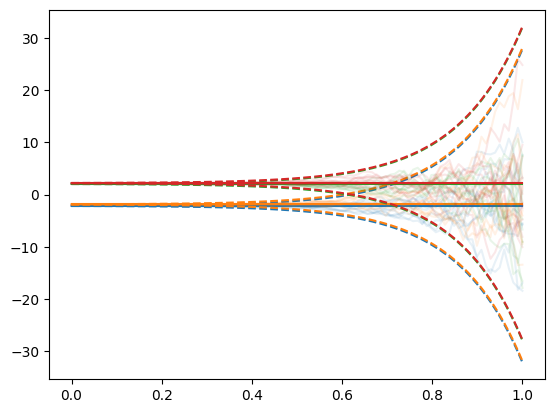

In [8]:
for i in range(4):
    j = i * 500
    _ = plt.plot(t,ys[:, :, j].T, color=f"C{i}", alpha=0.1)
    _ = plt.plot(t, mus[:, j], color=f"C{i}")
    _ = plt.plot(t, mus[:,j]+3*std[:, j], color=f"C{i}", linestyle="--")
    _ = plt.plot(t, mus[:, j]-3*std[:,j], color=f"C{i}", linestyle="--")

In [9]:
p = VPSDE(p0)
t = jnp.linspace(0., 1., 100)
ys = p.sample(key, t, (100,), method="srk3(2)")
mus = p.mean(t)
std = jnp.sqrt(p.variance(t))

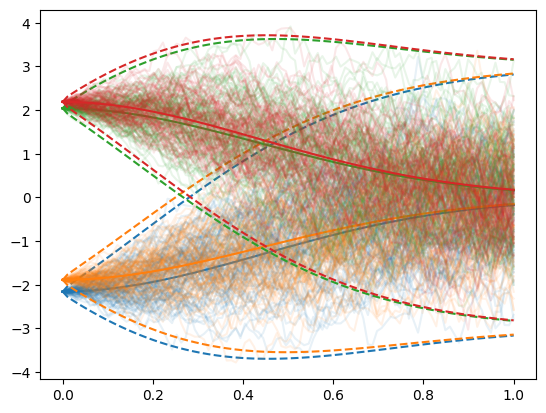

In [10]:
for i in range(4):
    j = i * 500
    _ = plt.plot(t,ys[:, :, j].T, color=f"C{i}", alpha=0.1)
    _ = plt.plot(t, mus[:, j], color=f"C{i}")
    _ = plt.plot(t, mus[:,j]+3*std[:, j], color=f"C{i}", linestyle="--")
    _ = plt.plot(t, mus[:, j]-3*std[:,j], color=f"C{i}", linestyle="--")

In [38]:
score_fn = jax.grad(lambda x, t: p.log_prob(x, t).sum())(jnp.ones((2000,)),jnp.ones((1,)))

(1, 2000)
(1, 2000)
(2000,)


In [22]:
p.log_prob(jnp.ones((2000,)), jnp.ones((1,)))

(1, 2000)
(1, 2000)
(2000,)


Array([[-2.57 , -2.556, -2.549, ..., -0.933, -0.934, -0.937]], dtype=float32)

In [ ]:
from typing import Callable

def filter(drift: Callable, diffusion: Callable, mu0, cov0, ts, t_o = None, y_o = None, C_o = None, R_o = None, method="ode"):

    mu0 = jnp.atleast_1d(mu0)
    cov0 = jnp.atleast_2d(cov0)
    ts = jnp.atleast_1d(ts)
    dtype = mu0.dtype
    # Check consistent shapes
    assert mu0.shape[0] == cov0.shape[0] == cov0.shape[1], "Dimension mismatch, cov0 must be a square matrix of shape (d,d) and mu0 must be a vector of shape (d,)"

    # Consistent dtype
    cov0 = cov0.astype(dtype)
    ts = ts.astype(dtype)
    _drift = lambda t,x: jnp.atleast_1d(drift(t, x)).astype(dtype)
    _diffusion = lambda t, x: jnp.atleast_2d(diffusion(t,x)).astype(dtype)

    # If we condition on observations
    if t_o is None:
        assert y_o is None, "If t_o is not provided, y_o must not be provided"
        ts_merged = ts
        observed_index_array = jnp.zeros(len(ts_merged), dtype=jnp.int32)
    else:
        index_observed = jnp.searchsorted(ts, t_o)
        ts_merged = jnp.insert(ts, index_observed, t_o)
        index_observed = jnp.searchsorted(ts_merged, t_o)
        observed_mask_array = jnp.zeros(len(ts_merged), dtype=jnp.int32).at[index_observed].set(1)
        observed_index_array = observed_mask_array.cumsum()

    





In [17]:
A = jnp.array([[-0.5]])

def drift(t, x):
    return jnp.matmul(A, x)

@jax.jit
def jac(t, x):
    return A 

jac_jax = jax.jit(jax.jacfwd(drift, argnums=1))

In [19]:
%%timeit 
jac(0., jnp.ones((1,)))

287 µs ± 3.57 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [20]:
%%timeit 
jac_jax(0., jnp.ones((1,)))

98.4 µs ± 1.44 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
def predict_linear_ode(t, data, A, B):
    mu0, cov0 = data
    mu = jnp.dot(A, mu0)
    cov = jnp.dot(A, cov0) + jnp.dot(cov0, A.T) + jnp.dot(B, B.T)
    return mu, cov

In [13]:
_predict(0. ,0.1, jnp.ones(1), jnp.ones(1))

(Array([0.951], dtype=float32), Array([[0.929]], dtype=float32))

In [14]:
from probjax.inference.kalman_filter import kalman_filter, predict_discrete, update
from functools import partial
_predict = partial(predict_discrete, drift_matrix = lambda x,t: jnp.array([[-0.5]]), diffusion_matrix = lambda x,t: jnp.array([[0.5]]))
kalman_filter(t, jnp.ones(1)*0.5,jnp.eye(1), _predict, update,  jnp.array([0.5]), jnp.array([0.5]), jnp.array([[1.]]), jnp.array([[1.]]))

(Array([[0.5  ],
        [0.435],
        [0.429],
        [0.33 ],
        [0.254],
        [0.195],
        [0.15 ],
        [0.115],
        [0.089],
        [0.068],
        [0.052],
        [0.04 ],
        [0.031],
        [0.024],
        [0.018],
        [0.014],
        [0.011],
        [0.008],
        [0.006],
        [0.005],
        [0.004]], dtype=float32),
 Array([[[1.   ]],
 
        [[0.413]],
 
        [[0.409]],
 
        [[0.344]],
 
        [[0.306]],
 
        [[0.283]],
 
        [[0.269]],
 
        [[0.261]],
 
        [[0.257]],
 
        [[0.254]],
 
        [[0.252]],
 
        [[0.251]],
 
        [[0.251]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]]], dtype=float32),
 Array([[0.5  ],
        [0.389],
        [0.429],
        [0.33 ],
        [0.254],
        [0.195],
        [0.15 ],
        [0.115],
        [0.089],
        [0.068],


In [31]:
?kalman_filter

Signature:
kalman_filter(
    ts: jax.Array,
    mu0: jax.Array,
    cov0: jax.Array,
    predict: Callable,
    update: Callable,
    t_o: jax.Array,
    y_o: jax.Array,
    C_o: jax.Array,
    R_o: jax.Array,
) -> Tuple[jax.Array, jax.Array, jax.Array, jax.Array]
Docstring:
Kalman filter for a discrete time model on time grid ts.

Args:
    ts (Array): Time grid to filter on.
    mu0 (Array): Starting mean
    cov0 (Array): Starting covariance
    predict (Callable): Prediction function
    update (Callable): Update function
    t_o (Array): Observation times
    y_o (Array): Observation values
    C_o (Array): Observation projection matrix
    R_o (Array): Observation noise covariance matrix

Returns:
    Tuple[Array, Array, Array, Array]: Mean and covs at observation times, and mean and covs at all times.
File:      /mnt/c/Users/manug/OneDrive/Uni/PHD/probjax/probjax/inference/kalman_filter.py
Type:      function

In [25]:
_sdeint = partial(sdeint, self.drift, self.diffusion, **kwargs)
shape = ts.shape + sample_shape + self.batch_shape + self.event_shape
key1, key2 = jax.random.split(key)
x0 = self.p0.sample(key1, sample_shape)
x0_flat = x0.reshape(-1, *self.event_shape)
ys = sdeint(self.drift, self.diffusion, x0, ts, **kwargs)

NameError: name 'self' is not defined

In [38]:
from functools import partial
kwargs = {"method": "euler_maruyama"}
_sdeint = partial(sdeint, **kwargs)
_sdeint = jax.vmap(_sdeint, in_axes=(0,None,None, 0,None))
key = jax.random.split(key, 100)
x0 = x0.repeat(100, axis=0).reshape(100, 1)
ys = _sdeint(key, f,g, x0, t)

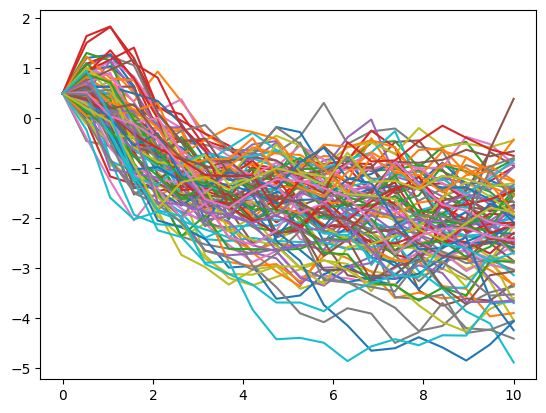

In [39]:
_ = plt.plot(t, jnp.squeeze(ys).T)

In [39]:
B = jnp.ones((3, 2, 2))
c = jnp.array([0.3333,0.3333, 0.3333])

jnp.einsum("ijk,i->jk", B, c)


Array([[0.9999, 0.9999],
       [0.9999, 0.9999]], dtype=float32)

In [40]:
jnp.einsum("i,i -> i", c, c)

Array([0.11108889, 0.11108889, 0.11108889], dtype=float32)

In [42]:
jnp.ones((3,2)) @ jnp.ones((2,))

Array([2., 2., 2.], dtype=float32)

In [26]:
?jnp.dot

Signature:      jnp.dot(a, b, *, precision=None)
Call signature: jnp.dot(*args, **kwargs)
Type:           PjitFunction
String form:    <PjitFunction of <function dot at 0x7fed84bc0f70>>
File:           ~/miniconda3/envs/rvtorch/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py
Docstring:     
Dot product of two arrays. Specifically,

LAX-backend implementation of :func:`numpy.dot`.

In addition to the original NumPy arguments listed below, also supports
``precision`` for extra control over matrix-multiplication precision
on supported devices. ``precision`` may be set to ``None``, which means
default precision for the backend, a :class:`~jax.lax.Precision` enum value
(``Precision.DEFAULT``, ``Precision.HIGH`` or ``Precision.HIGHEST``) or a tuple
of two :class:`~jax.lax.Precision` enums indicating separate precision for each argument.

*Original docstring below.*

- If both `a` and `b` are 1-D arrays, it is inner product of vectors
  (without complex conjugation).

- If both `a` a

In [13]:
c.shape

(3,)

In [40]:
from functools import partial

def f(x, t, a):
    return a*x

g = partial(f, a=0.1)

g.keywords["a"] = 0.2

In [41]:
g.

functools.partial(<function f at 0x7f76b47168c0>, a=0.2)

In [12]:
from probjax.core import inverse, inverse_and_logabsdet

def g(x0):
    ys = odeint(f, x0, t, method="bosh3")
    y1 = ys[-1]
    return y1

y1 = g(jnp.ones((1,)))
g_inv = inverse(g)

jaxpr = jax.make_jaxpr(g)(jnp.ones((1,)))

In [20]:
jaxpr.eqns[-2]

a:f32[1,1] = dynamic_slice[slice_sizes=(1, 1)] b c d

In [4]:
logdet

Array(1.524, dtype=float32)

In [22]:
f(x0, t[0])

Array([-1., -1.], dtype=float32)

In [21]:
# def _inv_logdet_odeint(drift, y0, ts, *args, **kwargs):
#     drift_jac = jax.jacobian(drift, argnums=1)

#     def aug_drift(t, x, *args):
#         print("X",x.shape)
#         x = x[:-1]
#         x_new = drift(t, x, *args)
#         jac = drift_jac(t, x, *args)
#         print(jac.shape)
#         if jac.ndim > 2:
#             logdet_new = jnp.diagonal(jac, axis1=-2, axis2=-1).sum().reshape((1,))
#         else:
#             logdet_new = jac.sum().reshape((1,))

#         return jnp.concatenate([x_new, logdet_new])

#     y0_extended = jnp.concatenate([y0, jnp.zeros((1,))])
#     print(y0_extended.shape)
#     ys_extended = odeint(aug_drift, y0_extended, ts, *args, **kwargs)
#     ys = ys_extended[:, :-1]
#     logdet = ys_extended[-1, -1]

#     return ys, logdet

# with jax.disable_jit():
#     _inv_logdet_odeint(f, x0, t, method="euler")

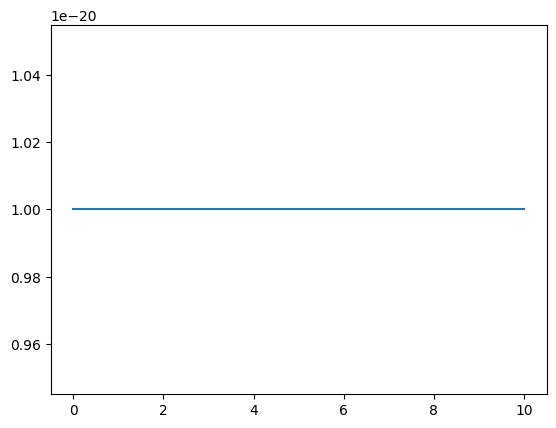

In [3]:
ys = odeint(f, x0*1e-20, t[::-1], method="heun_euler")

plt.plot(t, ys[::-1])

# ys = odeint(lambda x,t : f(-x, t), x0*1e-20, t, method="rk3(2)")
# plt.plot(t, ys)

In [ ]:
from jax import lax
from typing import Callable, Tuple, Union
from jax import Array

def explicit_stochastic_runge_kutta_step(
    drift: Callable,
    diffusion: Callable,
    t0: Array,
    y0: Array,
    f0: Array,
    g0: Array,
    dt: Array,
    dWt: Array,
    dWtdWs: Array,
    c0: Array,
    c1: Array,
    A0: Array,
    A1: Array,
    B0: Array,
    B1: Array,
    b_sol: Array,
    gamma0: Array,
    gamma1: Array,
    b_error: Array,
    order: int,
):
    def body_fun(i, k1, k2):
        ti1 = t0 + dt * c0[i - 1]
        ti2 = t0 + dt * c1[i - 1]

        yi1 = y0 + dt.astype(f0.dtype) * jnp.dot(A0[i - 1, :], k1) + dWt * jnp.dot(B1[i - 1, :], k2)
        yi2 = y0 + dt.astype(f0.dtype) * jnp.dot(A1[i - 1, :], k1) + jnp.sqrt(dt) * jnp.dot(B1[i - 1, :], k2)

        ft = drift(yi1, ti1)
        gt = diffusion(yi2, ti2)
        return k1.at[i, :].set(ft), k2.at[i, :].set(gt)

    k1 = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
    k2 = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
    k1,k2 = lax.fori_loop(1, order, body_fun, k1, k2)

    y1 = y0 + dt.astype(f0.dtype) * jnp.dot(b_sol, k1) + dWt * jnp.dot(gamma0, k2) + dWtdWs * jnp.dot(gamma1, k2)
    f1 = k1[-1]
    g1 = k2[-1]

    if b_error is None:
        y1_error = None
    else:
        raise NotImplementedError

    return y1, f1,g1, (y1_error, k1,k2)

euler


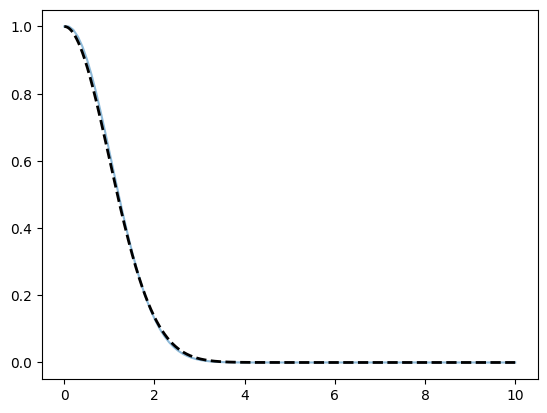

heun


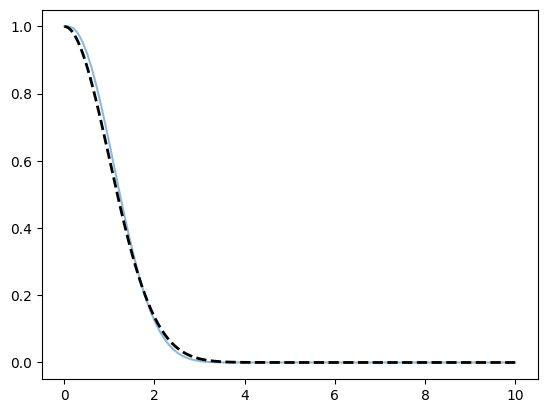

heun_euler


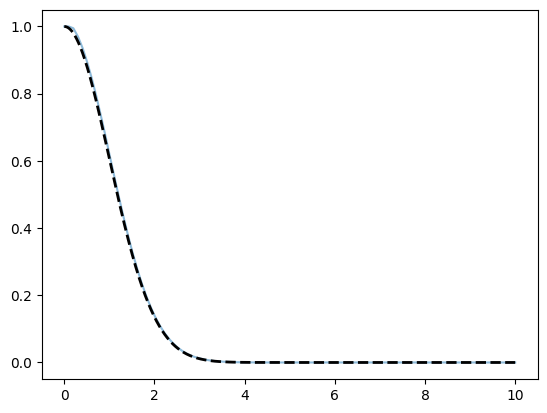

midpoint


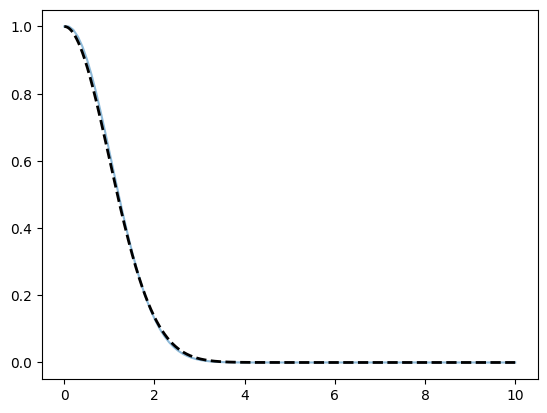

ralston


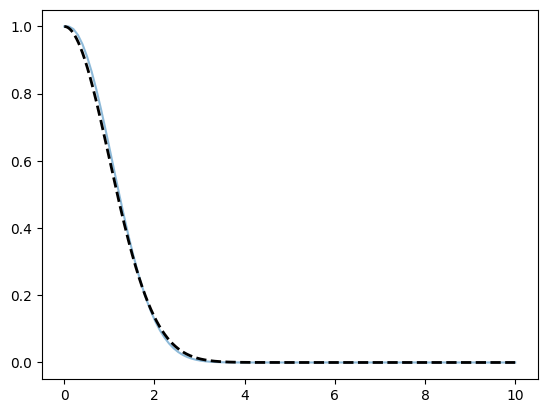

rk3


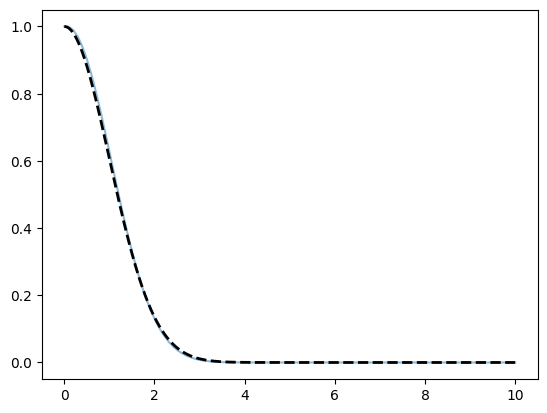

rk3(2)


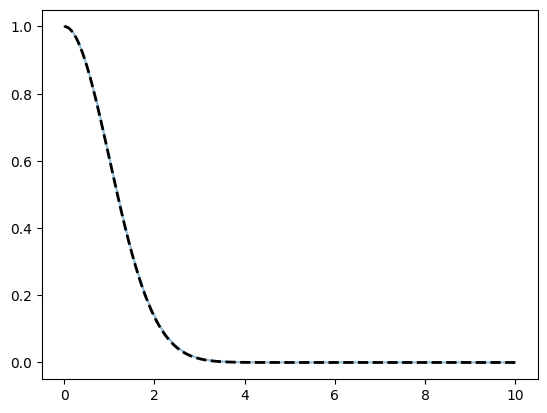

bosh3


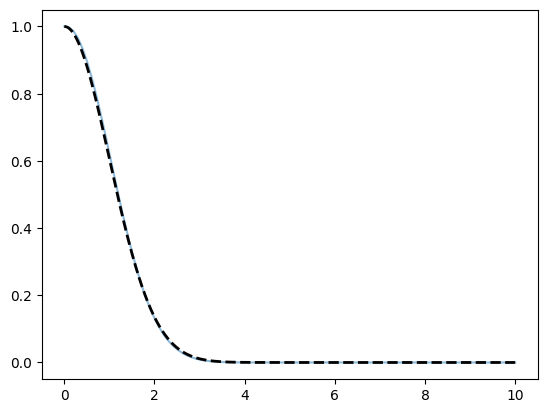

heun3


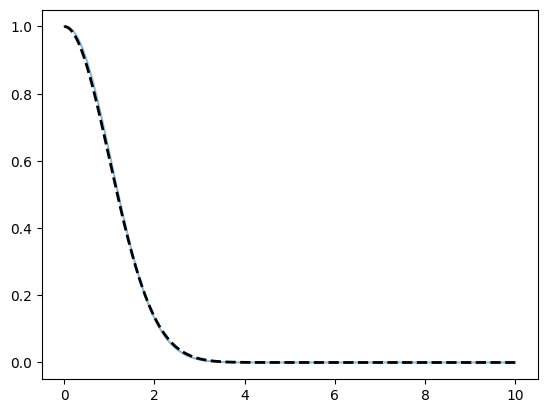

vanderhouwen


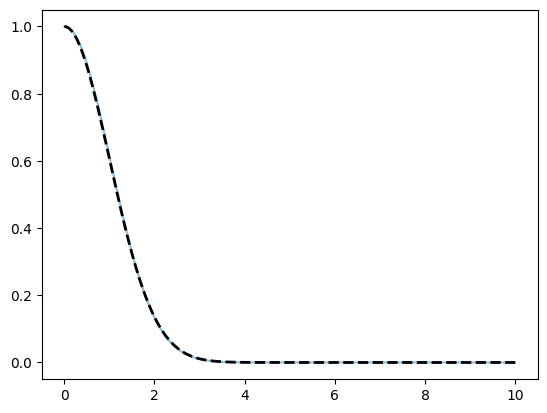

ralston3


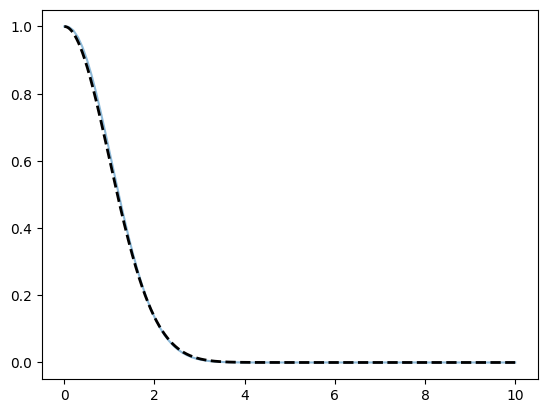

ssprk3


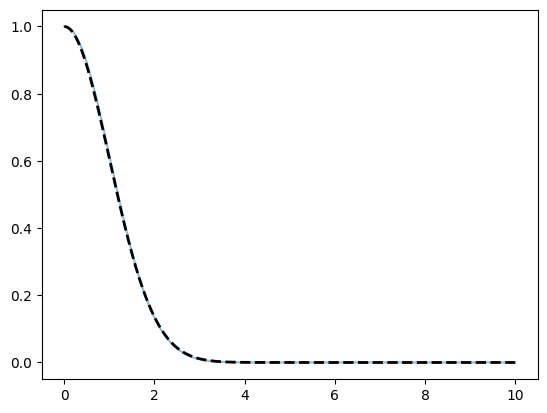

rk4


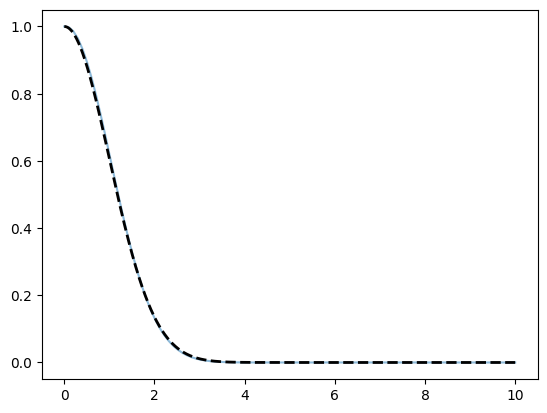

rk4(5)


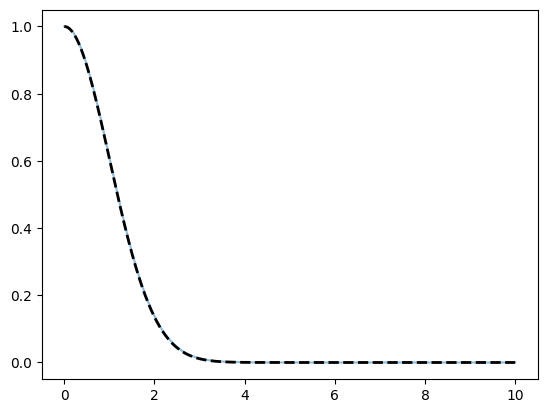

3/8


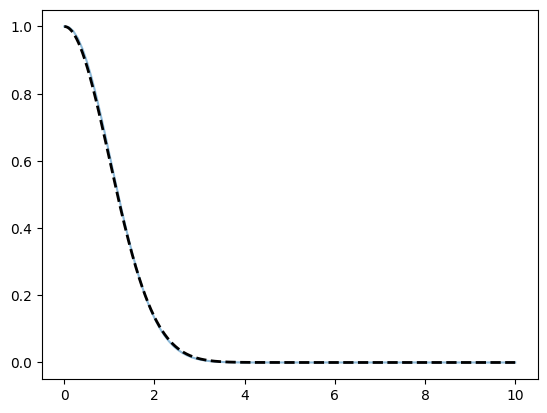

ralston4


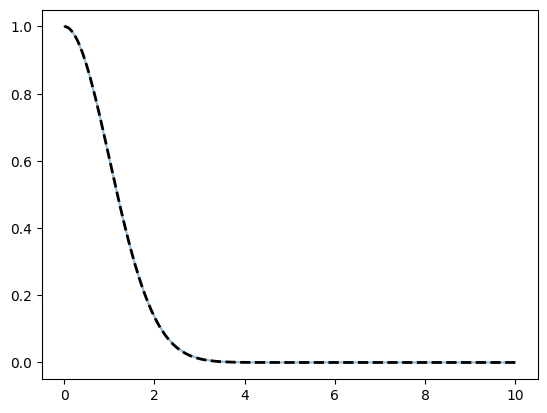

rk5(4)


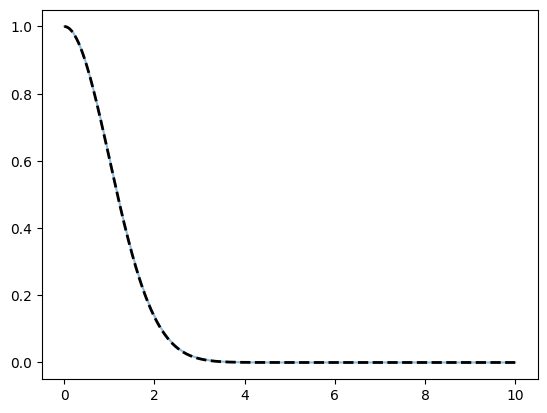

dopri5


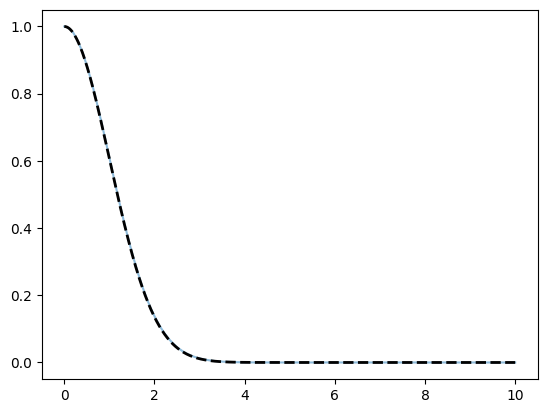

implicit_euler


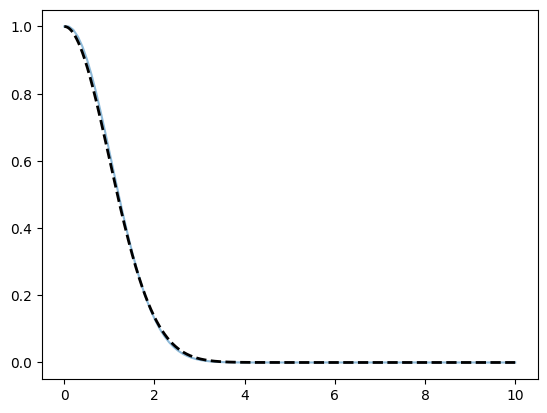

implicit_midpoint


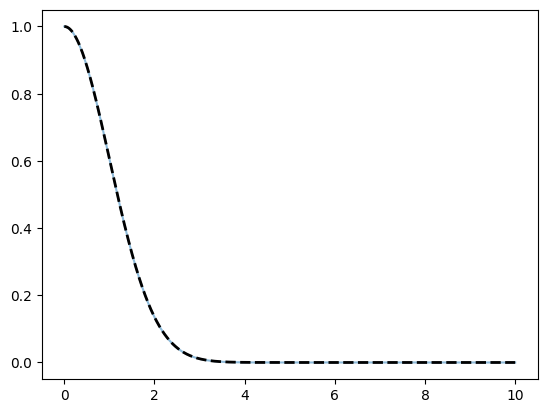

implicit_trapezoidal


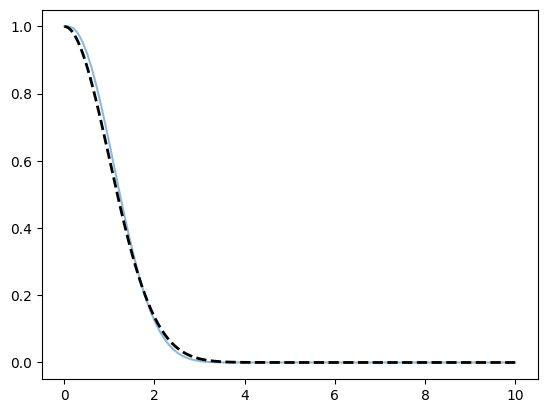

implicit_crank_nicolson


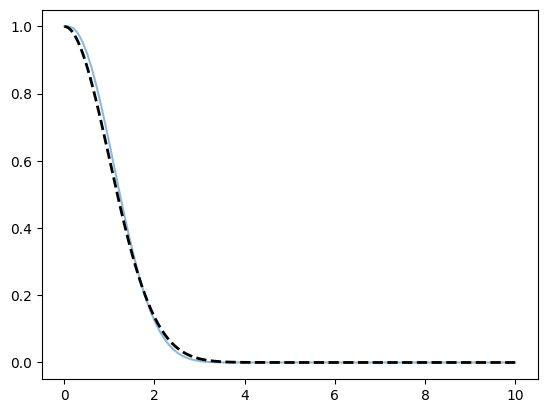

gauss_legendre


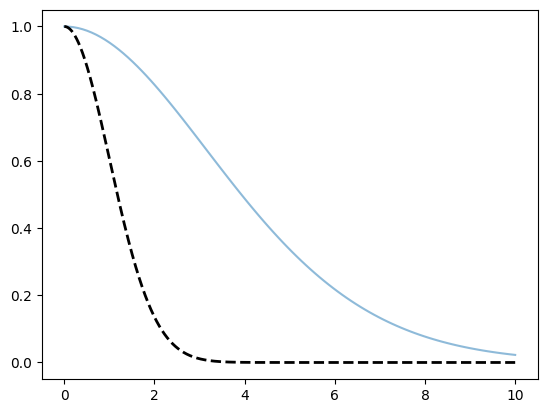

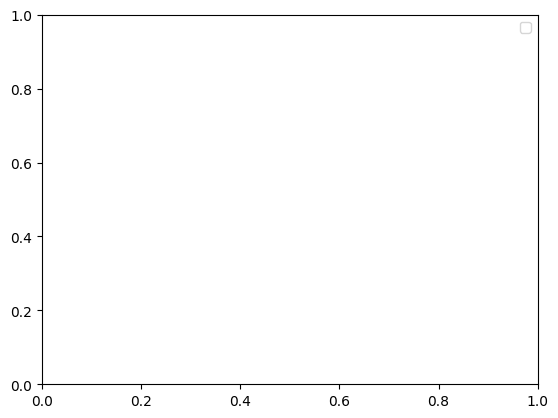

In [8]:
# odeint for all methods
from probjax.utils.odeint import odeint, get_methods

METHODS = get_methods()

for m in METHODS:
    print(m)
    #with jax.disable_jit():
    x = odeint(f, x0, t, method=m)
    
    plt.plot(t, x, label=m, alpha=0.5)
    plt.plot(jnp.linspace(0, 10, 10000), odeint(f, x0, jnp.linspace(0, 10, 10000), method="rk4"), color="black", lw=2, linestyle="--")
    plt.show()



plt.legend(METHODS + ["True"])

In [23]:
def f(x):
    return x**2 - 2

In [34]:
jnp.finfo(jnp.float32).eps

1.1920929e-07

In [37]:
from jax import lax
from functools import partial

METHODS = {}


c0 = jnp.array([0., 1.])
A0 = jnp.array([[0., 0.], [1., 0.]])
b_sol = jnp.array([0.5, 0.5])
b_error = jnp.array([1., 0.])

@partial(jax.jit, static_argnums=(0,))
def runge_kutta_step(func, y0, f0, t0, dt, c, A, b_sol, b_error, order=2):
  # Dopri5 Butcher tableaux

  def body_fun(i, k):
    ti = t0 + dt * c[i-1]
    yi = y0 + dt.astype(f0.dtype) * jnp.dot(A[i-1, :], k)
    ft = func(yi, ti)
    return k.at[i, :].set(ft)

  k = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
  k = lax.fori_loop(1, order, body_fun, k)

  y1 = dt.astype(f0.dtype) * jnp.dot(b_sol, k) + y0
  y1_error = dt.astype(f0.dtype) * jnp.dot(b_error, k)
  f1 = k[-1]
  return y1, f1, y1_error, k

In [52]:
jnp.linalg.is_tril(A0)

AttributeError: module 'jax.numpy.linalg' has no attribute 'is_tril'

In [44]:
%%timeit
runge_kutta_step(f, jnp.array([1.]), jnp.array([1.]), jnp.array([0.]), jnp.array([1.]), alpha, beta, c_sol, c_error)

424 µs ± 16.8 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [47]:
@partial(jax.jit, static_argnums=(0,))
def _heun_step(_f, t0, y0, dt):
    half_dt = dt / 2
    k1 = _f(t0, y0)
    k2 = _f(t0 + half_dt, y0 + half_dt * k1)
    return y0 + (k1 + k2)/2 * dt

In [51]:
%%timeit
_heun_step(f, jnp.array([0.]), jnp.array([1.]), jnp.array([1.]))

293 µs ± 23.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [29]:
def newton_raphson(f, x0, tol=1e-6, max_iter=50):
    """
    Newton-Raphson root-finding algorithm for a vector-valued function.
    
    Args:
    - f: A function that takes a vector x and returns a vector of the same shape.
    - x0: Initial guess for the root.
    - tol: Tolerance for stopping criterion (default: 1e-6).
    - max_iter: Maximum number of iterations (default: 100).
    
    Returns:
    - x: The estimated root of the function.
    """
    x = x0

    f_jax = jax.jacobian(f)

    def scan_fn(carry, i):
        tol_reached, x = carry

        def true_fn(x):
            return x, jnp.inf

        def false_fn(x):
            y = f(x)
            J = f_jax(x)
            delta_x = jax.scipy.linalg.solve(J, -y)
            x = x + delta_x
            return x, jnp.linalg.norm(delta_x)
        
        
        x, delta_x = jax.lax.cond(tol_reached, true_fn, false_fn, x)
        tol_reached = delta_x < tol
        return (tol_reached, x), x
      
    
    tol_reached = False
    _, x = jax.lax.scan(scan_fn, (tol_reached, x), jnp.arange(max_iter))
    return x[-1]

newton_raphson(f, jnp.array([100.]))

Array([1.414], dtype=float32)

In [30]:
from probjax.utils.interpolation import linear_interpolation

jax.vmap(linear_interpolation(t, x))(jnp.array([0.5, 0.75])).shape

(2, 1)

In [20]:

from functools import partial
from typing import Optional, Tuple, Union
from jax import Array 
from jaxtyping import Float


jax.jit
def _generate_grid(ts: jnp.ndarray, dt_max: Optional[float] = None):
    """Generate a grid of time points that satisfy the minimum dt

    Args:
        ts (jnp.ndarray): Time points.
        max_dt (Optional[float], optional): Maximum dt. Defaults to None.

    Returns:
        jnp.ndarray: Grid of time points.
    """
    dts = ts[1:] - ts[:-1]
    dts_expension = jnp.ceil(dts / dt_max)

    def scan_fn(t_prev, dt):
        def true_fn(dt):
            return t_prev + dt
        
        def false_fn(dt):
            
            def cond_fn(t):
                return t < t_prev + dt
            
            def body_fn(t):
                return t + dt
            
            return jax.lax.while_loop(cond_fn, body_fn, t_prev)
        return t, grid
    
    _, grid = jax.lax.scan(scan_fn, (ts[0],), dts)
    

In [33]:
dt_max = 0.1
ts = jnp.array([0.0, 0.1, 0.35,0.5])
dts  = ts[1:] - ts[:-1]

dts_extension = jnp.ceil(dts/dt_max)

dts_extension

Array([1., 3., 2.], dtype=float32)

In [26]:
@jax.jit 
def f(ts):
    T_max = ts[-1]
    T_min = ts[0]
    ts = _generate_grid(ts, T_max, T_min, max_dt=0.1)

In [27]:
f(t)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=2/0)>
The problem arose with the `int` function. If trying to convert the data type of a value, try using `x.astype(int)` or `jnp.array(x, int)` instead.
The error occurred while tracing the function _generate_grid at /tmp/ipykernel_10811/4238015521.py:7 for jit. This value became a tracer due to JAX operations on these lines:

  operation a:f32[] = sub b c
    from line /tmp/ipykernel_10811/4238015521.py:21 (_generate_grid)

  operation a:f32[] = convert_element_type[new_dtype=float32 weak_type=False] b
    from line /tmp/ipykernel_10811/4238015521.py:21 (_generate_grid)

See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.ConcretizationTypeError

In [25]:
ts.shape

(1100,)

In [28]:
ts[:100]

Array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004,
       0.004, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,
       0.005, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006,
       0.006, 0.006, 0.007, 0.007, 0.007, 0.007, 0.007, 0.007, 0.007,
       0.007, 0.007, 0.007, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008,
       0.008, 0.008, 0.008, 0.008, 0.009, 0.009, 0.009, 0.009, 0.009,
       0.009, 0.009, 0.009, 0.009, 0.009, 0.01 , 0.01 , 0.01 , 0.01 ,
       0.01 ], dtype=float32)